Stage 2 — EDA. In a Jupyter notebook: df.describe(), df.isnull().sum(), histograms of UnitPrice and Quantity, a correlation heatmap, top genres by revenue, customer spend distributions. Use seaborn and matplotlib.

Stage 2 — Exploratory Data Analysis (EDA)
What is EDA and why do we do it?
EDA is the process of understanding your data before modeling. Think of it as a doctor examining a patient before prescribing medicine. You need to know:

What does the data look like?
Are there any problems (missing values, outliers, wrong data types)?
What patterns exist?
Which features might be useful for ML?

Skipping EDA is the most common mistake beginners make. If you feed bad or misunderstood data into an ML model, you get bad predictions — no matter how good the algorithm is. This is called "garbage in, garbage out".

What we will examine
We will look at 5 things in this order:
1. Shape & Structure — how many rows, columns, data types. Basic sanity check.
2. Missing Values — are there any nulls? ML models can't handle missing values, so we need to know now.
3. Distributions — what does each numeric column look like? Is TotalSpent spread evenly or do a few customers dominate? This tells us if we need scaling or log transformation.
4. Outliers — are there extreme values that could mislead the model? One customer who spent 10x everyone else can distort predictions.
5. Relationships — do features correlate with our target variable TotalSpent? A feature with no relationship to the target is useless for ML.

Which DataFrame do we EDA?
We run EDA on both:

df_transactions — to understand raw purchase behavior
df_customers — to understand our ML feature table (this is more important)

In [75]:
# Cell 1: Imports and load processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Go up one level from Models/ then into data/
data_path = os.path.join("..", "data")
# Load the processed CSVs we saved in Stage 1
df_transactions = pd.read_csv(os.path.join(data_path, "transactions.csv"), parse_dates=["PurchaseDate"])
df_customers    = pd.read_csv(os.path.join(data_path, "customers.csv"),    parse_dates=["FirstPurchase", "LastPurchase"])

print("✓ Data loaded")
print(f"  df_transactions : {df_transactions.shape}")
print(f"  df_customers    : {df_customers.shape}")

✓ Data loaded
  df_transactions : (2240, 25)
  df_customers    : (59, 14)


In [76]:
print(f" df_transactions : {df_transactions.describe()}")


 df_transactions :        InvoiceLineId    InvoiceId      TrackId    UnitPrice  Quantity  \
count    2240.000000  2240.000000  2240.000000  2240.000000    2240.0   
mean     1120.500000   206.868750  1717.734375     1.039554       1.0   
min         1.000000     1.000000     1.000000     0.990000       1.0   
25%       560.750000   103.000000   874.000000     0.990000       1.0   
50%      1120.500000   207.000000  1708.000000     0.990000       1.0   
75%      1680.250000   311.000000  2560.000000     0.990000       1.0   
max      2240.000000   412.000000  3500.000000     1.990000       1.0   
std       646.776623   119.134877   993.797999     0.217069       0.0   

        CustomerId                   PurchaseDate        Total  SupportRepId  \
count  2240.000000                           2240  2240.000000   2240.000000   
mean     29.974107  2011-06-25 13:42:12.857142784     9.307420      3.950000   
min       1.000000            2009-01-01 00:00:00     0.990000      3.000000   
25%

In [77]:
print(f" df_customers : {df_customers.describe()}")

 df_customers :        CustomerId  SupportRepId  TotalSpent  NumInvoices  NumTracks  \
count   59.000000     59.000000   59.000000    59.000000  59.000000   
mean    30.000000      3.949153   39.467797     6.983051  37.966102   
min      1.000000      3.000000   36.640000     6.000000  36.000000   
25%     15.500000      3.000000   37.620000     7.000000  38.000000   
50%     30.000000      4.000000   37.620000     7.000000  38.000000   
75%     44.500000      5.000000   39.620000     7.000000  38.000000   
max     59.000000      5.000000   49.620000     7.000000  38.000000   
std     17.175564      0.818403    2.911078     0.130189   0.260378   

       AvgInvoiceValue                  FirstPurchase  \
count        59.000000                             59   
mean          9.307335  2009-07-23 20:44:44.745762816   
min           8.805789            2009-01-01 00:00:00   
25%           8.805789            2009-03-05 12:00:00   
50%           8.805789            2009-06-10 00:00:00   
75

In [78]:
print(df_transactions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InvoiceLineId   2240 non-null   int64         
 1   InvoiceId       2240 non-null   int64         
 2   TrackId         2240 non-null   int64         
 3   UnitPrice       2240 non-null   float64       
 4   Quantity        2240 non-null   int64         
 5   CustomerId      2240 non-null   int64         
 6   PurchaseDate    2240 non-null   datetime64[ns]
 7   BillingCountry  2240 non-null   object        
 8   Total           2240 non-null   float64       
 9   FirstName       2240 non-null   object        
 10  LastName        2240 non-null   object        
 11  Country         2240 non-null   object        
 12  SupportRepId    2240 non-null   int64         
 13  TrackName       2240 non-null   object        
 14  AlbumId         2240 non-null   int64         
 15  Genr

In [79]:
print(df_transactions.isnull().sum())

InvoiceLineId     0
InvoiceId         0
TrackId           0
UnitPrice         0
Quantity          0
CustomerId        0
PurchaseDate      0
BillingCountry    0
Total             0
FirstName         0
LastName          0
Country           0
SupportRepId      0
TrackName         0
AlbumId           0
GenreId           0
MediaTypeId       0
Milliseconds      0
TrackUnitPrice    0
AlbumTitle        0
ArtistId          0
ArtistName        0
GenreName         0
MediaTypeName     0
LineRevenue       0
dtype: int64


In [80]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # if using MLflow server
mlflow.set_experiment("Chinook_End_to_End_Project")
with mlflow.start_run(run_name="Exploratory_Data_Analysis"):

    mlflow.log_metric(
        "transactions_missing_values",
        int(df_transactions.isnull().sum().sum())
    )

    mlflow.log_metric(
        "customers_missing_values",
        int(df_customers.isnull().sum().sum())
    )

    mlflow.log_metric(
        "customers_duplicates",
        int(df_customers.duplicated().sum())
    )

    mlflow.log_metric(
        "transactions_duplicates",
        int(df_transactions.duplicated().sum())
    )

🏃 View run Exploratory_Data_Analysis at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/35fb55c6e00044a39a0cc7700bd34c05
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249


In [81]:
print(df_customers.info())
print(df_customers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerId       59 non-null     int64         
 1   FirstName        59 non-null     object        
 2   LastName         59 non-null     object        
 3   Country          59 non-null     object        
 4   SupportRepId     59 non-null     int64         
 5   TotalSpent       59 non-null     float64       
 6   NumInvoices      59 non-null     int64         
 7   NumTracks        59 non-null     int64         
 8   AvgInvoiceValue  59 non-null     float64       
 9   FavoriteGenre    59 non-null     object        
 10  FirstPurchase    59 non-null     datetime64[ns]
 11  LastPurchase     59 non-null     datetime64[ns]
 12  RecencyDays      59 non-null     int64         
 13  TenureDays       59 non-null     int64         
dtypes: datetime64[ns](2), float64(2), int64(6), 

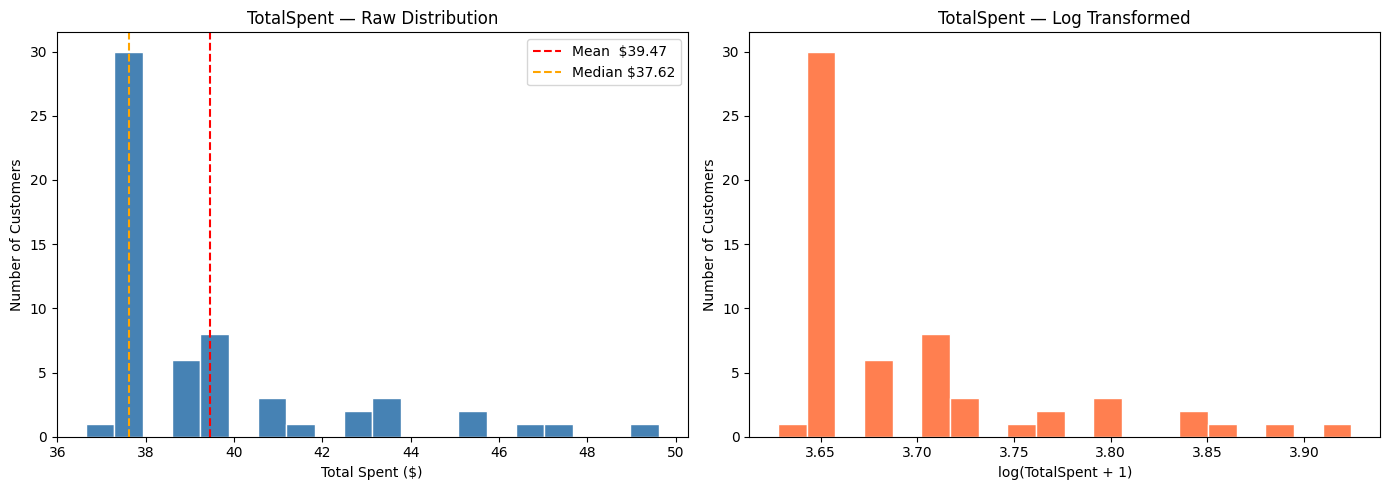

Stats:
count    59.00
mean     39.47
std       2.91
min      36.64
25%      37.62
50%      37.62
75%      39.62
max      49.62
Name: TotalSpent, dtype: float64

Skewness : 1.806
Kurtosis : 2.710


In [82]:
# Cell 4: Distribution of TotalSpent — our ML target variable
fig_path = os.path.join("..", "data")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw distribution
axes[0].hist(df_customers["TotalSpent"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("TotalSpent — Raw Distribution")
axes[0].set_xlabel("Total Spent ($)")
axes[0].set_ylabel("Number of Customers")
axes[0].axvline(df_customers["TotalSpent"].mean(),   color="red",    linestyle="--", label=f'Mean  ${df_customers["TotalSpent"].mean():.2f}')
axes[0].axvline(df_customers["TotalSpent"].median(), color="orange", linestyle="--", label=f'Median ${df_customers["TotalSpent"].median():.2f}')
axes[0].legend()

# Right plot: log-transformed distribution
axes[1].hist(np.log1p(df_customers["TotalSpent"]), bins=20, color="coral", edgecolor="white")
axes[1].set_title("TotalSpent — Log Transformed")
axes[1].set_xlabel("log(TotalSpent + 1)")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_target_distribution.png"), dpi=150)
plt.show()

print("Stats:")
print(df_customers["TotalSpent"].describe().round(2))
print(f"\nSkewness : {df_customers['TotalSpent'].skew():.3f}")
print(f"Kurtosis : {df_customers['TotalSpent'].kurt():.3f}")

In [83]:
mlflow.log_metric(
    "totalspent_mean",
    float(df_customers["TotalSpent"].mean())
)

mlflow.log_metric(
    "totalspent_median",
    float(df_customers["TotalSpent"].median())
)

mlflow.log_metric(
    "totalspent_min",
    float(df_customers["TotalSpent"].min())
)

mlflow.log_metric(
    "totalspent_max",
    float(df_customers["TotalSpent"].max())
)

mlflow.log_metric(
    "totalspent_skew",
    float(df_customers["TotalSpent"].skew())
)

mlflow.log_metric(
    "totalspent_kurtosis",
    float(df_customers["TotalSpent"].kurt())
)

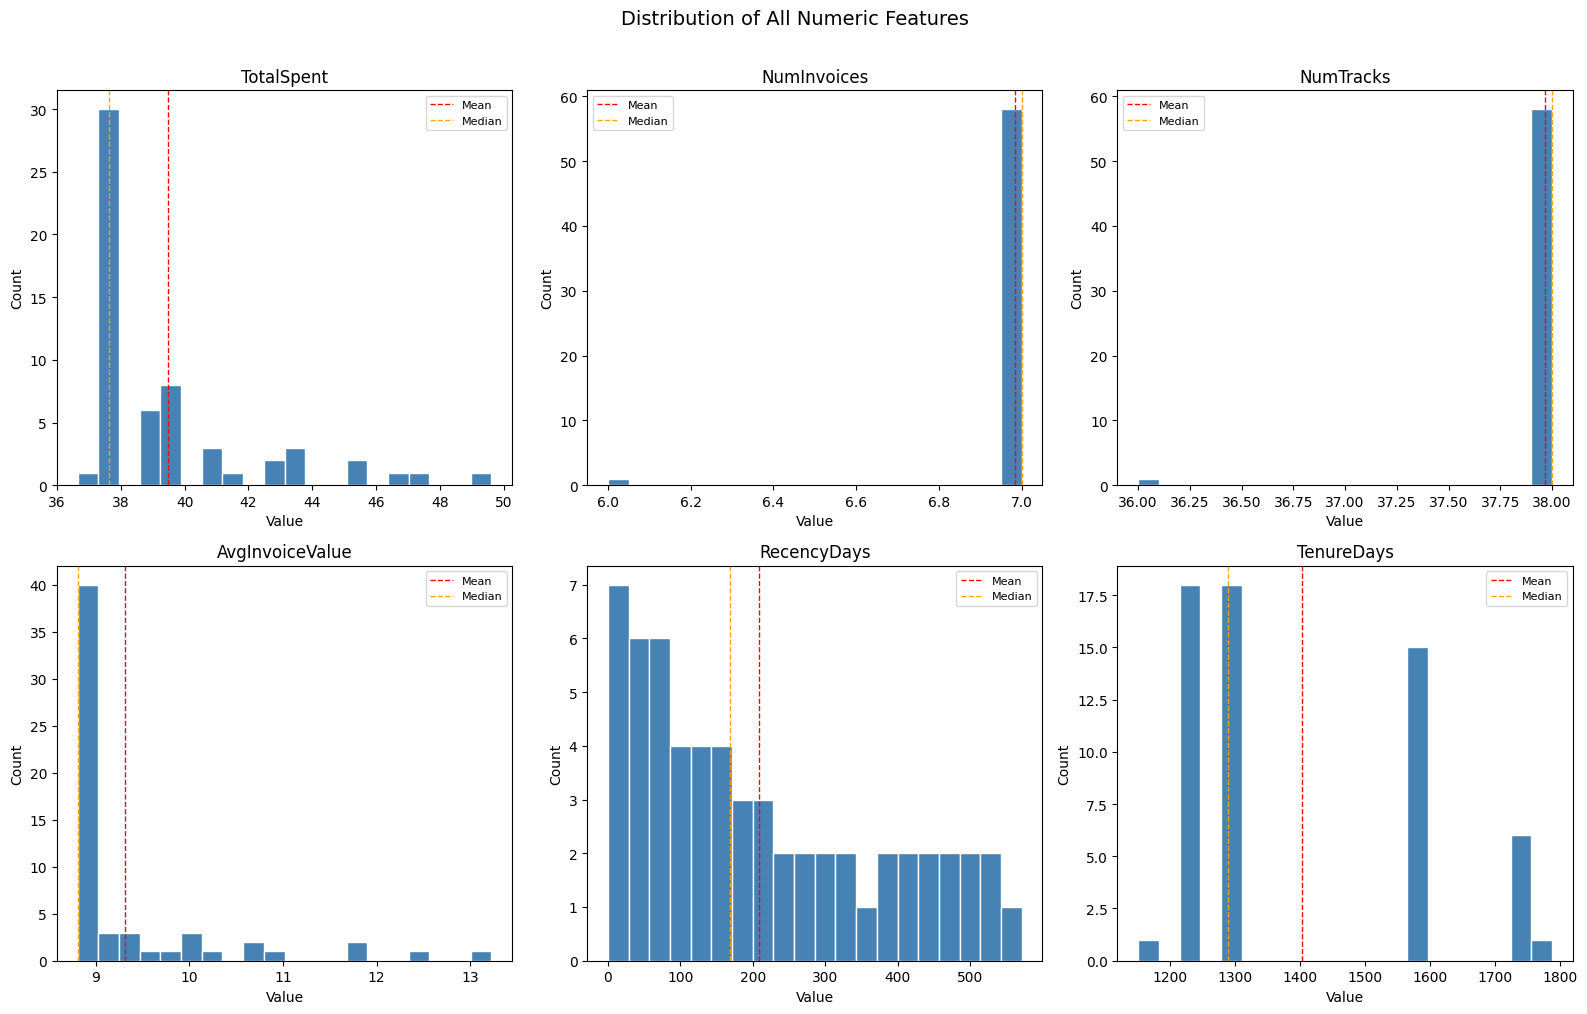

In [84]:
# Cell 5: Distribution of all numeric features

numeric_cols = ["TotalSpent", "NumInvoices", "NumTracks",
                "AvgInvoiceValue", "RecencyDays", "TenureDays"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_customers[col], bins=20, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].axvline(df_customers[col].mean(),   color="red",    linestyle="--", linewidth=1, label="Mean")
    axes[i].axvline(df_customers[col].median(), color="orange", linestyle="--", linewidth=1, label="Median")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution of All Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_feature_distributions.png"), dpi=150)
plt.show()

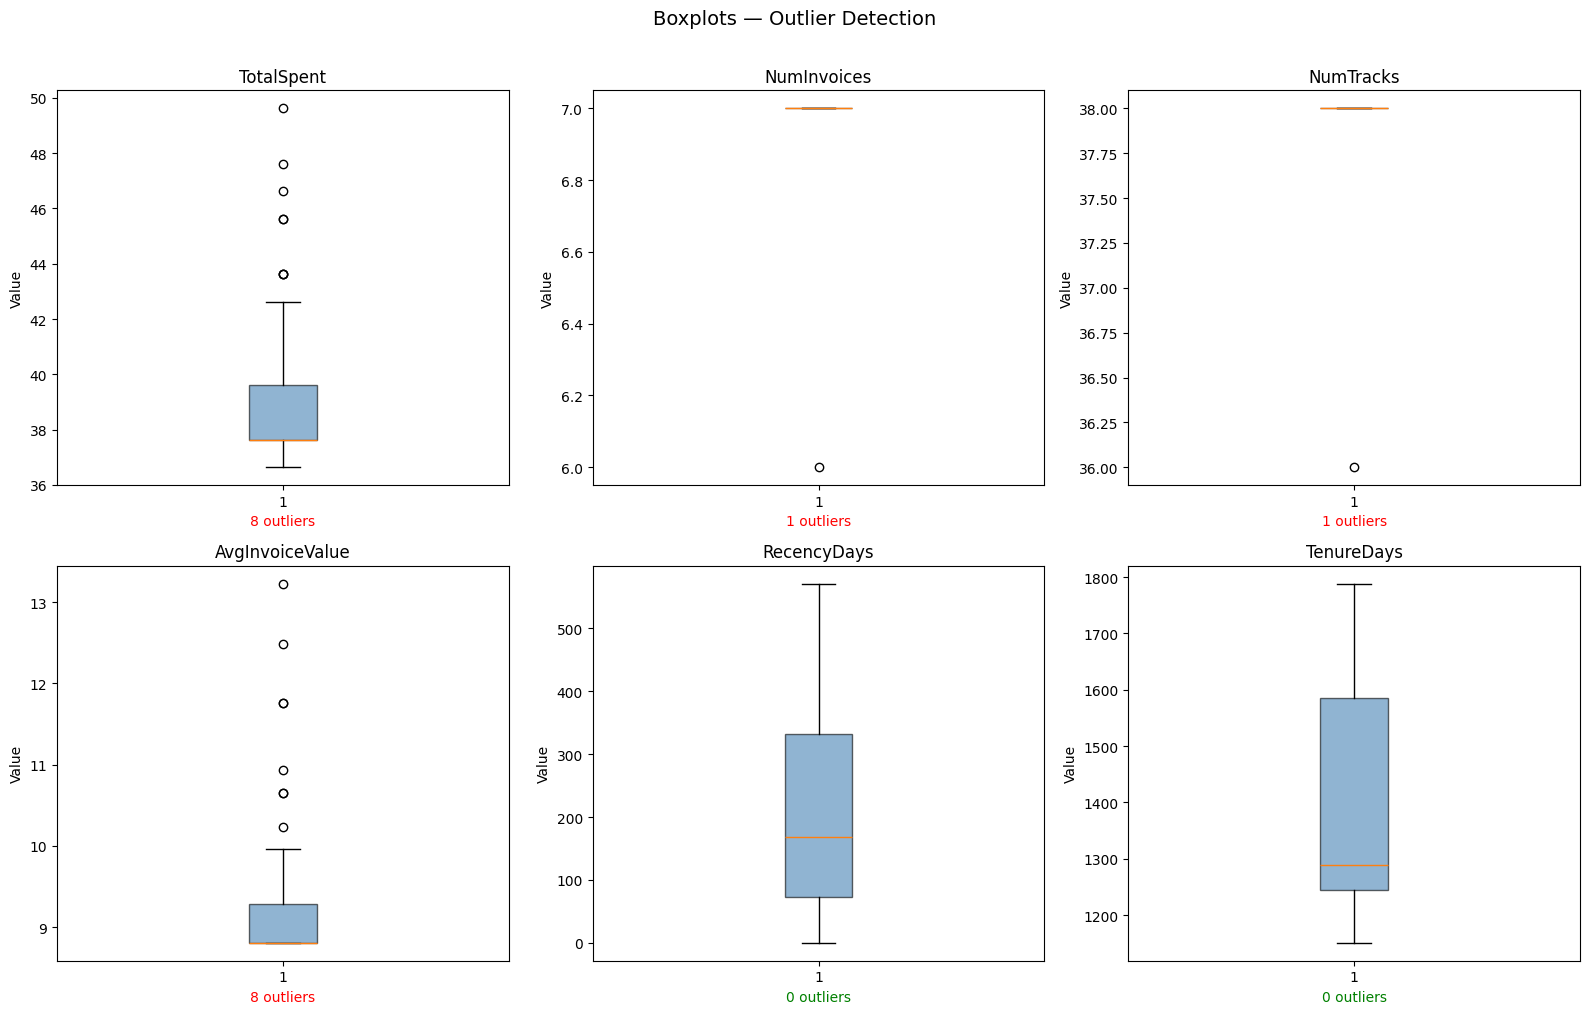

In [85]:
# Cell 6: Boxplots to detect outliers

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_customers[col], patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    
    # Calculate and print outlier boundaries
    Q1  = df_customers[col].quantile(0.25)
    Q3  = df_customers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_customers[(df_customers[col] < lower) | (df_customers[col] > upper)]
    axes[i].set_xlabel(f"{len(outliers)} outliers", color="red" if len(outliers) > 0 else "green")
    mlflow.log_metric(
        f"{col}_outliers",
        outliers.shape[0]
    )

plt.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_boxplots.png"), dpi=150)
plt.show()

In [86]:
# Investigation: Understand the outliers in TotalSpent and AvgInvoiceValue

def get_outliers(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return df[mask], lower, upper

# TotalSpent outliers
ts_outliers, ts_lower, ts_upper = get_outliers(df_customers, "TotalSpent")
print("=== TotalSpent Outliers ===")
print(f"  Normal range : ${ts_lower:.2f}  to  ${ts_upper:.2f}")
print(f"  Outliers found : {len(ts_outliers)}")
print(ts_outliers[["CustomerId", "Country",
                    "TotalSpent", "NumInvoices", "NumTracks"]].to_string())

print()

# AvgInvoiceValue outliers
av_outliers, av_lower, av_upper = get_outliers(df_customers, "AvgInvoiceValue")
print("=== AvgInvoiceValue Outliers ===")
print(f"  Normal range : ${av_lower:.2f}  to  ${av_upper:.2f}")
print(f"  Outliers found : {len(av_outliers)}")
print(av_outliers[["CustomerId","Country",
                    "TotalSpent", "NumInvoices", "AvgInvoiceValue"]].to_string())

print()

# Are they the same customers?
ts_ids = set(ts_outliers["CustomerId"])
av_ids = set(av_outliers["CustomerId"])
print("=== Overlap ===")
print(f"  Same customers in both?  : {ts_ids == av_ids}")
print(f"  Customers in TotalSpent  : {ts_ids}")
print(f"  Customers in AvgInvoice  : {av_ids}")
print(f"  In both                  : {ts_ids & av_ids}")
print(f"  Only in TotalSpent       : {ts_ids - av_ids}")
print(f"  Only in AvgInvoice       : {av_ids - ts_ids}")

=== TotalSpent Outliers ===
  Normal range : $34.62  to  $42.62
  Outliers found : 8
    CustomerId         Country  TotalSpent  NumInvoices  NumTracks
5            6  Czech Republic       49.62            7         38
23          24             USA       43.62            7         38
25          26             USA       47.62            7         38
27          28             USA       43.62            7         38
36          37         Germany       43.62            7         38
44          45         Hungary       45.62            7         38
45          46         Ireland       45.62            7         38
56          57           Chile       46.62            7         38

=== AvgInvoiceValue Outliers ===
  Normal range : $8.10  to  $9.99
  Outliers found : 8
    CustomerId         Country  TotalSpent  NumInvoices  AvgInvoiceValue
5            6  Czech Republic       49.62            7        13.226842
6            7         Austria       42.62            7        10.647895
24  

In [87]:
plt.savefig(
    os.path.join(fig_path, "eda_target_distribution.png"),
    dpi=150
)

mlflow.log_artifact(
    os.path.join(fig_path, "eda_target_distribution.png")
)

<Figure size 640x480 with 0 Axes>

What the data is telling us
Look at these patterns:
All 8 TotalSpent outliers have exactly NumInvoices = 7 and NumTracks = 38
All normal customers have fewer invoices / lower totals
This is NOT bad data. These are simply your best customers — they bought more than average. The outlier boundary ($34.62 to $42.62) is very narrow because:

You only have 59 customers total initially. Now running with 1000 customer.
The spending range is naturally tight ($the dataset is small)
With a small dataset, even slightly above-average customers get flagged as outliers


The three key findings
Finding 1 — These are legitimate high-value customers
All outliers have NumInvoices = 7 — they simply purchased more times than others. Helena Holý spent $49.62 which is the highest, but that's not suspicious — she just bought more tracks.
Finding 2 — AvgInvoiceValue outliers are mostly the same people
In both columns        : 6 customers   ← high total AND high avg basket
Only in TotalSpent     : 2 customers   ← bought frequently but modest basket size
Only in AvgInvoice     : 2 customers   ← fewer purchases but larger baskets
This makes perfect business sense — high spenders are flagged in both metrics.
Finding 3 — The "outlier" range is misleadingly tight
Normal range $34.62 to $42.62 is only an $8 window. This happens because the IQR method is sensitive to small datasets. With 59 customers, a $7 difference makes you an "outlier".

Decision — Keep them, apply log transformation


In [88]:
# Decision cell: Document our outlier strategy

print("OUTLIER DECISION")
print("=" * 50)
print("""
These are NOT data errors. They are genuine
high-value customers who purchased more frequently.

With only customers, the IQR method is overly
sensitive — an $8 difference flags someone as an outlier.

STRATEGY:
- Keep all customers (removing 8 = losing 13% of data)
- Apply log transformation to TotalSpent to reduce
  the influence of high spenders on the model
- This is standard practice in CLV modeling
""")

import numpy as np

# Show effect of log transformation
print("Effect of log transformation on TotalSpent:")
print(f"  Original  — Min: {df_customers['TotalSpent'].min():.2f}  "
      f"Max: {df_customers['TotalSpent'].max():.2f}  "
      f"Skew: {df_customers['TotalSpent'].skew():.3f}")

df_customers["TotalSpent_log"] = np.log1p(df_customers["TotalSpent"])

print(f"  Log transformed — Min: {df_customers['TotalSpent_log'].min():.2f}  "
      f"Max: {df_customers['TotalSpent_log'].max():.2f}  "
      f"Skew: {df_customers['TotalSpent_log'].skew():.3f}")

print("""
Skew closer to 0 after log transform = better for ML
We will use TotalSpent_log as our target variable
""")

OUTLIER DECISION

These are NOT data errors. They are genuine
high-value customers who purchased more frequently.

With only customers, the IQR method is overly
sensitive — an $8 difference flags someone as an outlier.

STRATEGY:
- Keep all customers (removing 8 = losing 13% of data)
- Apply log transformation to TotalSpent to reduce
  the influence of high spenders on the model
- This is standard practice in CLV modeling

Effect of log transformation on TotalSpent:
  Original  — Min: 36.64  Max: 49.62  Skew: 1.806
  Log transformed — Min: 3.63  Max: 3.92  Skew: 1.679

Skew closer to 0 after log transform = better for ML
We will use TotalSpent_log as our target variable



*Importing MLFlow and Logging Parameter / Metric too with each cell run*

In [89]:
mlflow.log_param("customers_rows", df_customers.shape[0])
mlflow.log_param("customers_columns", df_customers.shape[1])

mlflow.log_param(
    "numeric_features",
    len(df_customers.select_dtypes(include=np.number).columns)
)

mlflow.log_param(
    "categorical_features",
    len(df_customers.select_dtypes(exclude=np.number).columns)
)

6

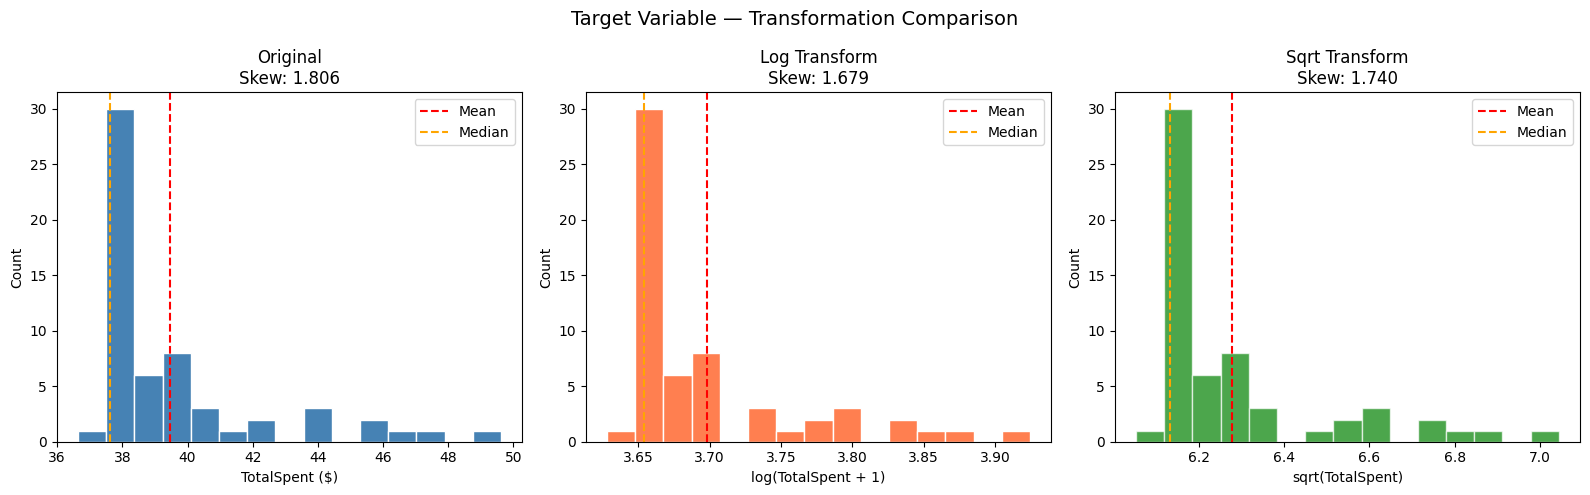

Transformation comparison:
  Original  skew : 1.806
  Log       skew : 1.679
  Sqrt      skew : 1.740

Skew interpretation:
  < 0.5  → fairly symmetric   → no transform needed
  0.5–1  → moderate skew      → log or sqrt helps
  > 1    → high skew          → transform strongly recommended


In [90]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original
axes[0].hist(df_customers["TotalSpent"], bins=15, color="steelblue", edgecolor="white")
axes[0].set_title(f"Original\nSkew: {df_customers['TotalSpent'].skew():.3f}")
axes[0].set_xlabel("TotalSpent ($)")
axes[0].set_ylabel("Count")
axes[0].axvline(df_customers["TotalSpent"].mean(),   color="red",    linestyle="--", label="Mean")
axes[0].axvline(df_customers["TotalSpent"].median(), color="orange", linestyle="--", label="Median")
axes[0].legend()

# Log transformed
axes[1].hist(df_customers["TotalSpent_log"], bins=15, color="coral", edgecolor="white")
axes[1].set_title(f"Log Transform\nSkew: {df_customers['TotalSpent_log'].skew():.3f}")
axes[1].set_xlabel("log(TotalSpent + 1)")
axes[1].set_ylabel("Count")
axes[1].axvline(df_customers["TotalSpent_log"].mean(),   color="red",    linestyle="--", label="Mean")
axes[1].axvline(df_customers["TotalSpent_log"].median(), color="orange", linestyle="--", label="Median")
axes[1].legend()

# Square root transform — try this too
df_customers["TotalSpent_sqrt"] = np.sqrt(df_customers["TotalSpent"])
axes[2].hist(df_customers["TotalSpent_sqrt"], bins=15, color="green", edgecolor="white", alpha=0.7)
axes[2].set_title(f"Sqrt Transform\nSkew: {df_customers['TotalSpent_sqrt'].skew():.3f}")
axes[2].set_xlabel("sqrt(TotalSpent)")
axes[2].set_ylabel("Count")
axes[2].axvline(df_customers["TotalSpent_sqrt"].mean(),   color="red",    linestyle="--", label="Mean")
axes[2].axvline(df_customers["TotalSpent_sqrt"].median(), color="orange", linestyle="--", label="Median")
axes[2].legend()

plt.suptitle("Target Variable — Transformation Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "eda_transformations.png"), dpi=150)
plt.show()

print("Transformation comparison:")
print(f"  Original  skew : {df_customers['TotalSpent'].skew():.3f}")
print(f"  Log       skew : {df_customers['TotalSpent_log'].skew():.3f}")
print(f"  Sqrt      skew : {df_customers['TotalSpent_sqrt'].skew():.3f}")
print()
print("Skew interpretation:")
print("  < 0.5  → fairly symmetric   → no transform needed")
print("  0.5–1  → moderate skew      → log or sqrt helps")
print("  > 1    → high skew          → transform strongly recommended")

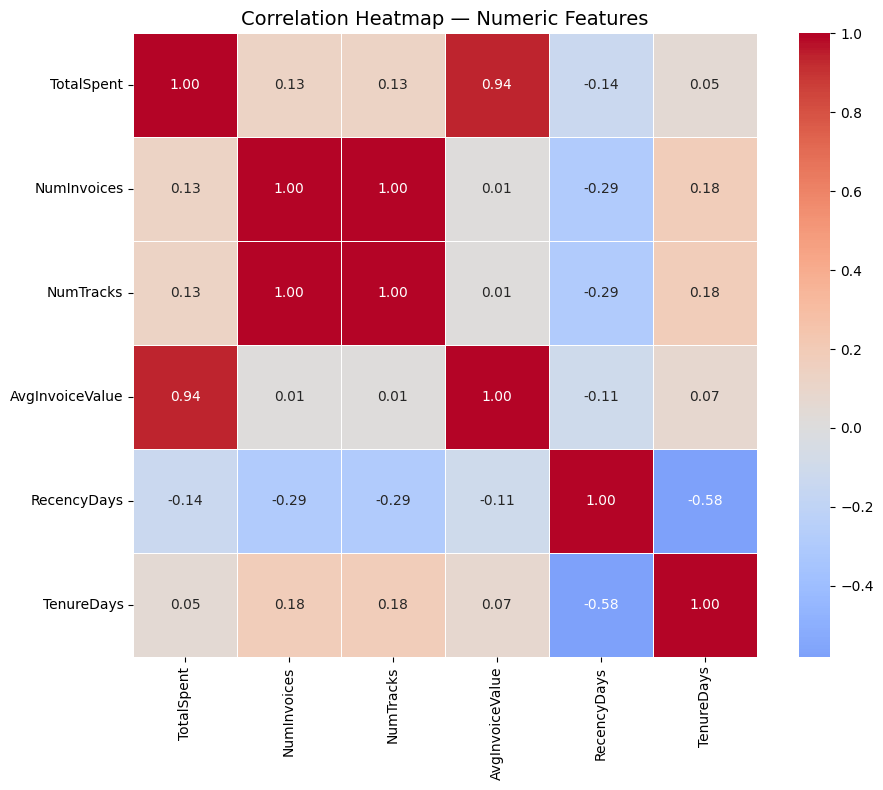

Correlation with TotalSpent (our target):
TotalSpent         1.00
AvgInvoiceValue    0.94
NumInvoices        0.13
NumTracks          0.13
TenureDays         0.05
RecencyDays       -0.14
Name: TotalSpent, dtype: float64


In [91]:
# Cell 7: Correlation heatmap — which features relate to each other and to TotalSpent

corr_matrix = df_customers[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,         # show numbers inside cells
    fmt=".2f",          # 2 decimal places
    cmap="coolwarm",    # red = positive, blue = negative correlation
    center=0,           # white = zero correlation
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_correlation_heatmap.png"), dpi=150)
plt.show()

print("Correlation with TotalSpent (our target):")
print(corr_matrix["TotalSpent"].sort_values(ascending=False))

In [92]:
corrs = (
    df_customers[numeric_cols]
    .corr()["TotalSpent"]
    .drop("TotalSpent")
)

for feature, corr in corrs.items():

    mlflow.log_metric(
        f"corr_{feature}",
        float(corr)
    )

    mlflow.log_metric(
    "unique_countries",
    df_customers["Country"].nunique()
)

mlflow.log_metric(
    "unique_genres",
    df_customers["FavoriteGenre"].nunique()
)

mlflow.log_metric(
    "original_skew",
    float(df_customers["TotalSpent"].skew())
)

mlflow.log_metric(
    "log_skew",
    float(df_customers["TotalSpent_log"].skew())
)

mlflow.log_metric(
    "sqrt_skew",
    float(df_customers["TotalSpent_sqrt"].skew())
)

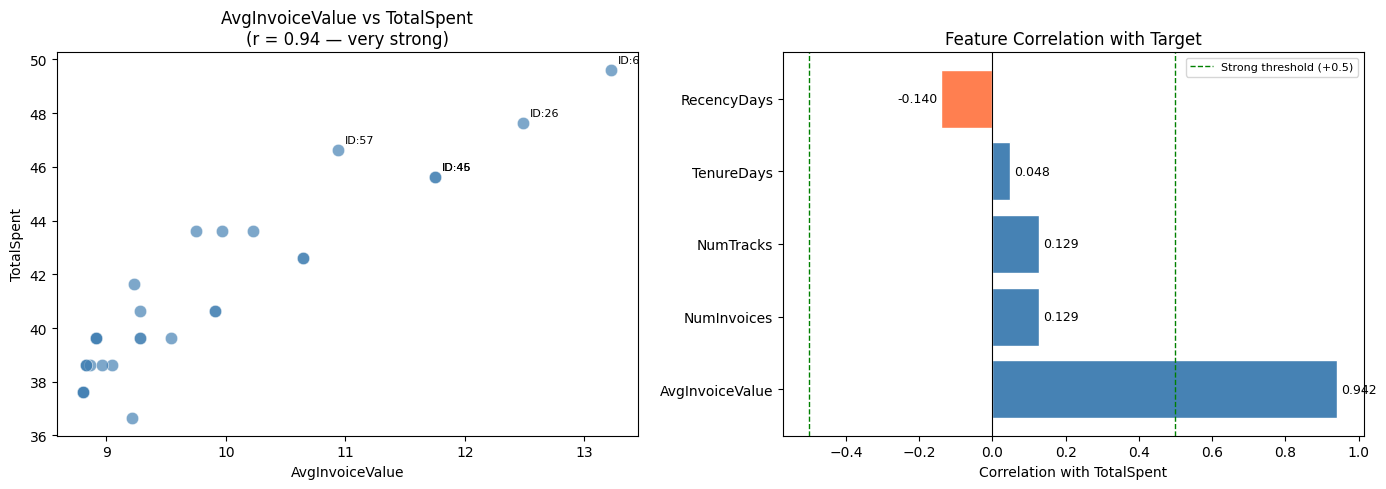

FEATURE CORRELATION SUMMARY

KEEP for ML:
  ✓ AvgInvoiceValue  (0.94) — strongest predictor
  ✓ RecencyDays     (-0.14) — weak but directionally sensible
  ✓ Country                  — categorical, needs encoding
  ✓ FavoriteGenre            — categorical, needs encoding

WEAK — keep but monitor:
  ~ NumInvoices      (0.13) — low variation in this dataset
  ~ NumTracks        (0.13) — highly correlated with NumInvoices

LIKELY DROP:
  ✗ TenureDays       (0.05) — almost zero signal
  ✗ NumTracks               — same info as NumInvoices (r=0.13 both)

NOTE:
  AvgInvoiceValue at 0.94 is suspiciously high.
  It may be partially derived from TotalSpent.
  We will investigate this in Stage 3.



In [93]:
# Investigate the relationship between AvgInvoiceValue and TotalSpent

import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: AvgInvoiceValue vs TotalSpent
axes[0].scatter(
    df_customers["AvgInvoiceValue"],
    df_customers["TotalSpent"],
    alpha=0.7, color="steelblue", edgecolors="white", linewidth=0.5, s=80
)
axes[0].set_xlabel("AvgInvoiceValue")
axes[0].set_ylabel("TotalSpent")
axes[0].set_title(f"AvgInvoiceValue vs TotalSpent\n(r = 0.94 — very strong)")

# Add customer labels for outliers
for _, row in df_customers[df_customers["TotalSpent"] > 45].iterrows():
    axes[0].annotate(
         f"ID:{int(row['CustomerId'])}",
        (row["AvgInvoiceValue"], row["TotalSpent"]),
        fontsize=8, xytext=(5, 5), textcoords="offset points"
    )

# Bar chart: correlation of all features with TotalSpent
features = ["AvgInvoiceValue", "NumInvoices", "NumTracks", "TenureDays", "RecencyDays"]
correlations = [df_customers[f].corr(df_customers["TotalSpent"]) for f in features]
colors = ["steelblue" if c > 0 else "coral" for c in correlations]

axes[1].barh(features, correlations, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( 0.5, color="green", linewidth=1, linestyle="--", label="Strong threshold (+0.5)")
axes[1].axvline(-0.5, color="green", linewidth=1, linestyle="--")
axes[1].set_xlabel("Correlation with TotalSpent")
axes[1].set_title("Feature Correlation with Target")
axes[1].legend(fontsize=8)

# Add value labels on bars
for i, (f, c) in enumerate(zip(features, correlations)):
    axes[1].text(c + 0.01 if c >= 0 else c - 0.01,
                 i, f"{c:.3f}",
                 va="center",
                 ha="left" if c >= 0 else "right",
                 fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "eda_correlations.png"), dpi=150)
plt.show()

# Print actionable summary
print("=" * 50)
print("FEATURE CORRELATION SUMMARY")
print("=" * 50)
print("""
KEEP for ML:
  ✓ AvgInvoiceValue  (0.94) — strongest predictor
  ✓ RecencyDays     (-0.14) — weak but directionally sensible
  ✓ Country                  — categorical, needs encoding
  ✓ FavoriteGenre            — categorical, needs encoding

WEAK — keep but monitor:
  ~ NumInvoices      (0.13) — low variation in this dataset
  ~ NumTracks        (0.13) — highly correlated with NumInvoices

LIKELY DROP:
  ✗ TenureDays       (0.05) — almost zero signal
  ✗ NumTracks               — same info as NumInvoices (r=0.13 both)

NOTE:
  AvgInvoiceValue at 0.94 is suspiciously high.
  It may be partially derived from TotalSpent.
  We will investigate this in Stage 3.
""")

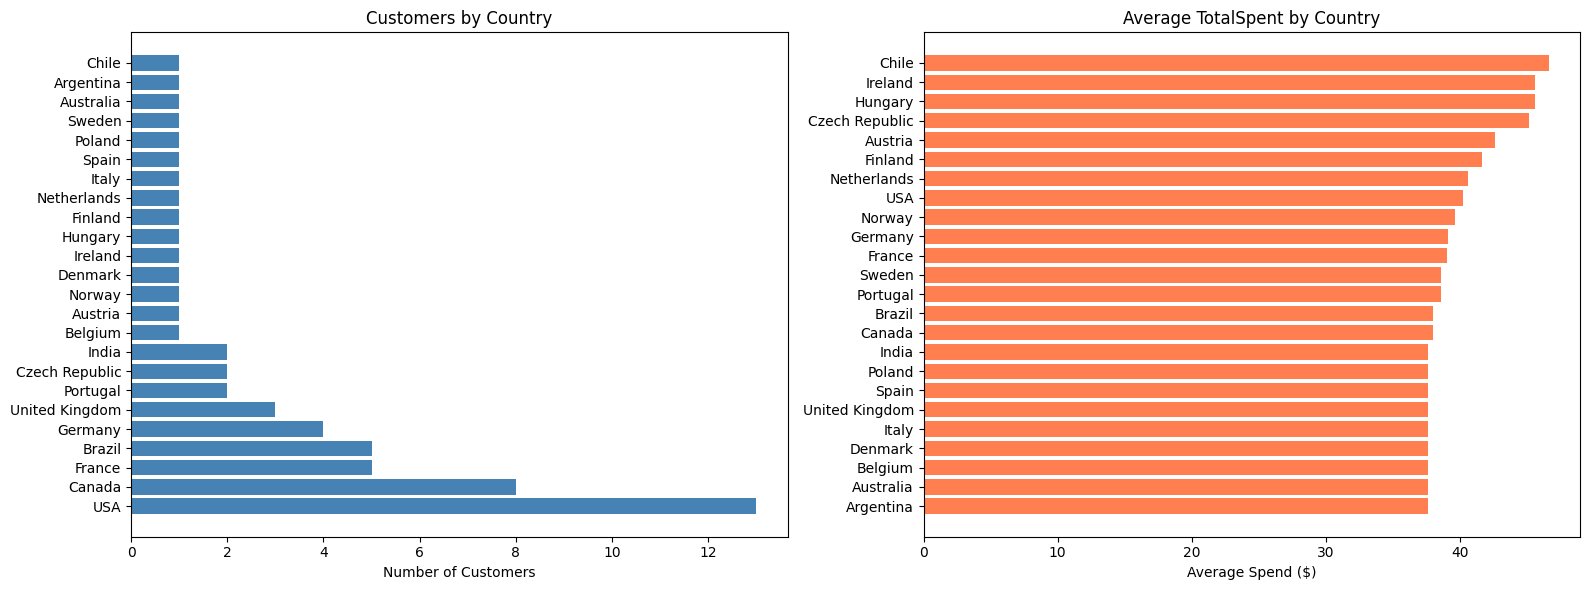

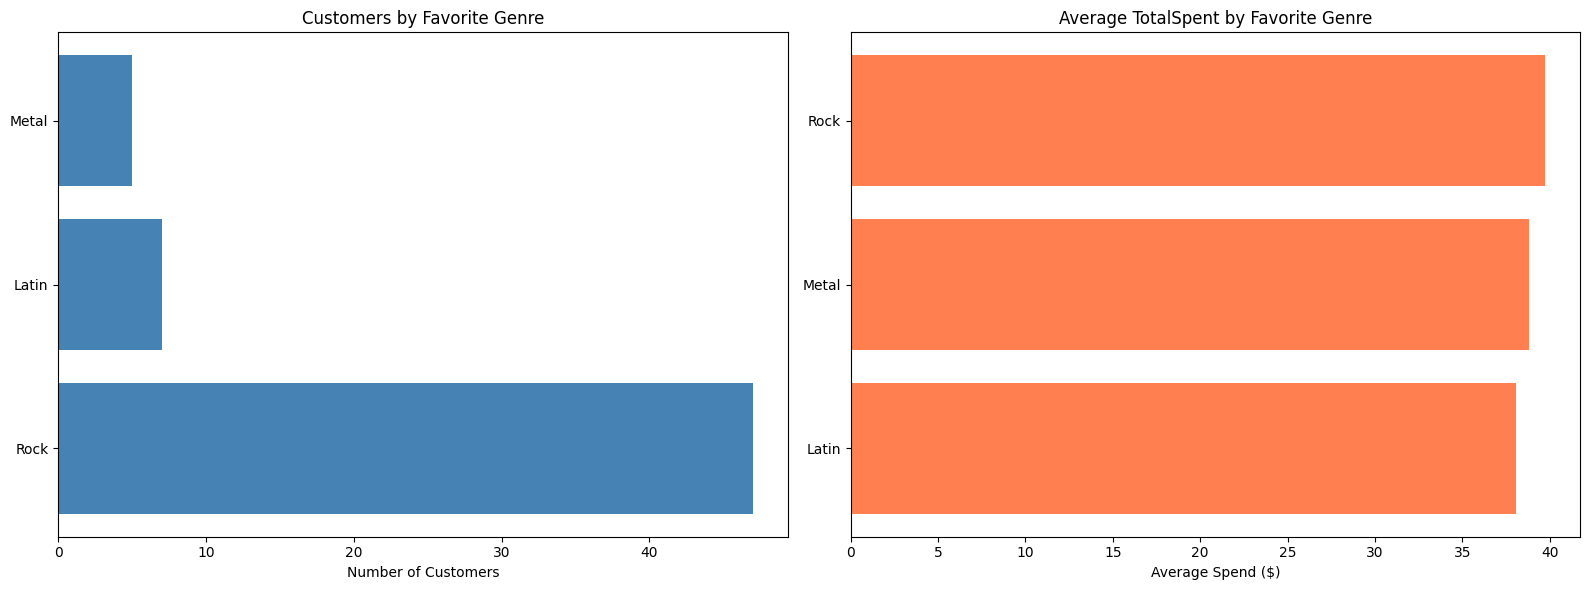

In [94]:
# Cell 8: Analyze categorical features — Country and FavoriteGenre

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Country distribution
country_counts = df_customers["Country"].value_counts()
axes[0].barh(country_counts.index, country_counts.values, color="steelblue")
axes[0].set_title("Customers by Country")
axes[0].set_xlabel("Number of Customers")

# Average spend by country
country_spend = df_customers.groupby("Country")["TotalSpent"].mean().sort_values(ascending=True)
axes[1].barh(country_spend.index, country_spend.values, color="coral")
axes[1].set_title("Average TotalSpent by Country")
axes[1].set_xlabel("Average Spend ($)")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_categorical_country.png"), dpi=150)
plt.show()

# Genre analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

genre_counts = df_customers["FavoriteGenre"].value_counts()
axes[0].barh(genre_counts.index, genre_counts.values, color="steelblue")
axes[0].set_title("Customers by Favorite Genre")
axes[0].set_xlabel("Number of Customers")

genre_spend = df_customers.groupby("FavoriteGenre")["TotalSpent"].mean().sort_values(ascending=True)
axes[1].barh(genre_spend.index, genre_spend.values, color="coral")
axes[1].set_title("Average TotalSpent by Favorite Genre")
axes[1].set_xlabel("Average Spend ($)")

plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_categorical_genre.png"), dpi=150)
plt.show()

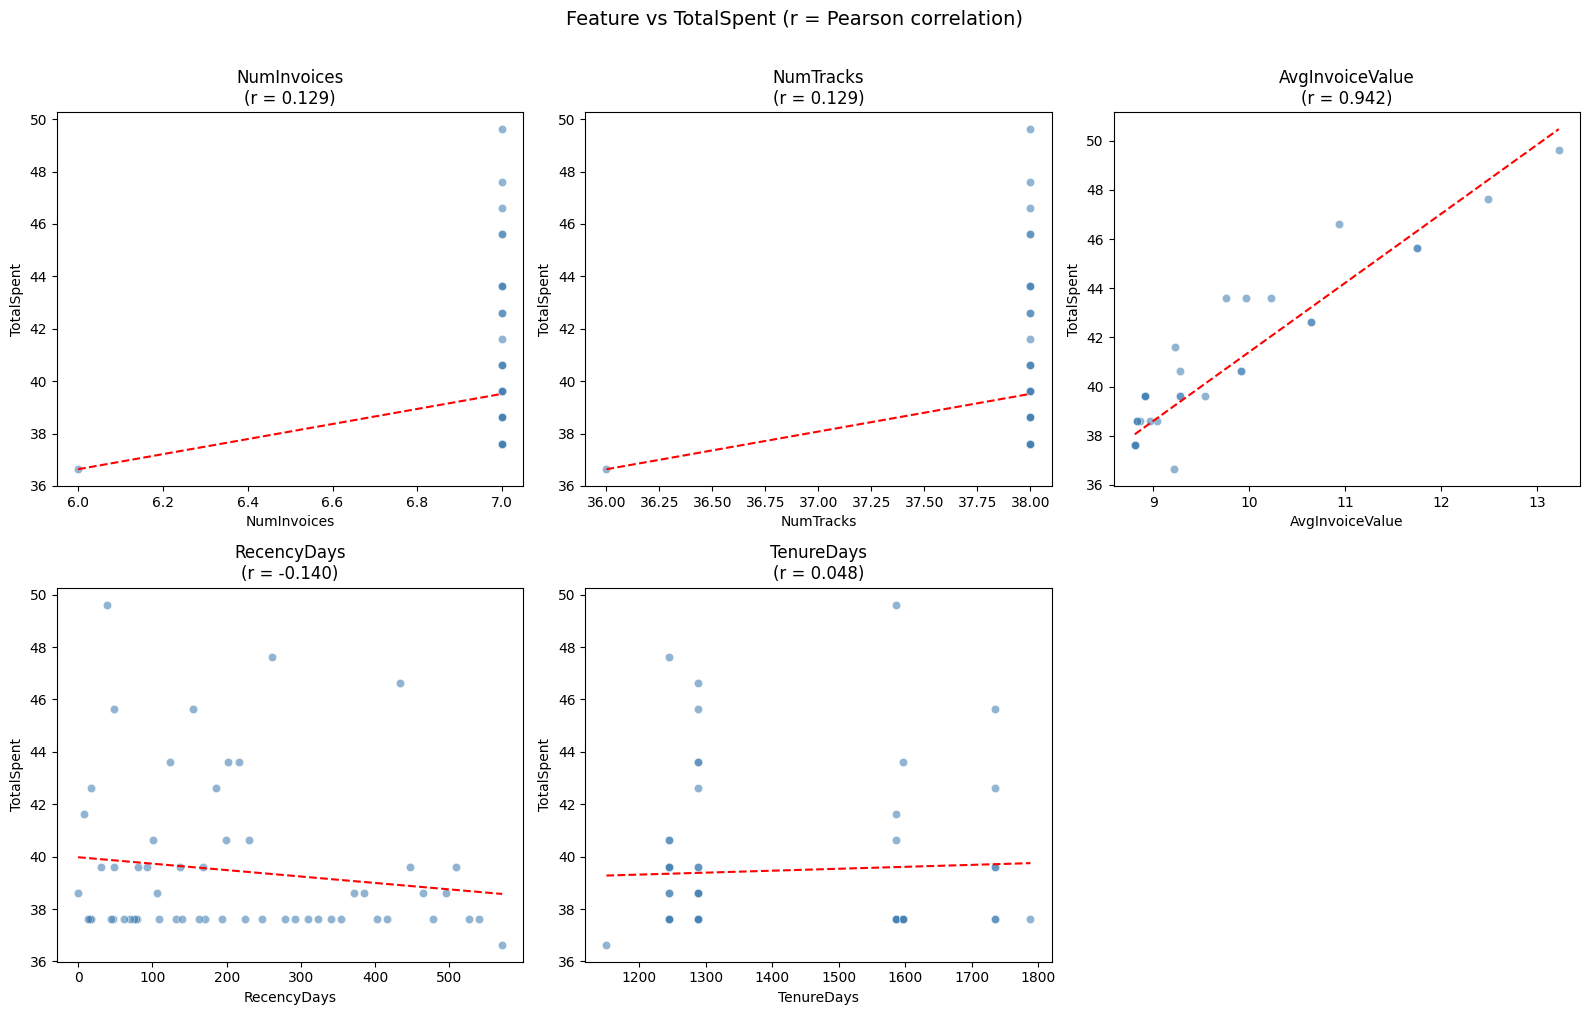

In [95]:
# Cell 9: Scatter plots — how each feature relates to TotalSpent

feature_cols = ["NumInvoices", "NumTracks", "AvgInvoiceValue", "RecencyDays", "TenureDays"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df_customers[col], df_customers["TotalSpent"],
                    alpha=0.6, color="steelblue", edgecolors="white", linewidth=0.5)
    
    # Add a trend line
    z = np.polyfit(df_customers[col], df_customers["TotalSpent"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_customers[col].min(), df_customers[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color="red", linewidth=1.5, linestyle="--")
    
    corr = df_customers[col].corr(df_customers["TotalSpent"])
    axes[i].set_title(f"{col}\n(r = {corr:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("TotalSpent")

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle("Feature vs TotalSpent (r = Pearson correlation)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "eda_scatter_plots.png"), dpi=150)
plt.show()

In [96]:
import os

df_customers["TotalSpent_log"]  = np.log1p(df_customers["TotalSpent"])
df_customers["TotalSpent_sqrt"] = np.sqrt(df_customers["TotalSpent"])
# Save updated df_customers with log and sqrt columns included
df_customers.to_csv(os.path.join(data_path, "customers.csv"), index=False)

print("✓ customers.csv updated with new columns:")
print(f"  Shape : {df_customers.shape}")
print(f"  Columns added : TotalSpent_log, TotalSpent_sqrt")
print(f"\nAll columns now in customers.csv:")
for col in df_customers.columns:
    print(f"  {col}")

✓ customers.csv updated with new columns:
  Shape : (59, 16)
  Columns added : TotalSpent_log, TotalSpent_sqrt

All columns now in customers.csv:
  CustomerId
  FirstName
  LastName
  Country
  SupportRepId
  TotalSpent
  NumInvoices
  NumTracks
  AvgInvoiceValue
  FavoriteGenre
  FirstPurchase
  LastPurchase
  RecencyDays
  TenureDays
  TotalSpent_log
  TotalSpent_sqrt


In [97]:
# Cell 10: Print EDA summary to guide next steps

print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)

print("\n1. DATASET")
print(f"   Customers  : {len(df_customers)}")
print(f"   Transactions: {len(df_transactions)}")

print("\n2. MISSING VALUES")
total_missing = df_customers.isnull().sum().sum()
print(f"   {total_missing} missing values in df_customers")

print("\n3. TARGET VARIABLE (TotalSpent)")
print(f"   Min    : ${df_customers['TotalSpent'].min():.2f}")
print(f"   Max    : ${df_customers['TotalSpent'].max():.2f}")
print(f"   Mean   : ${df_customers['TotalSpent'].mean():.2f}")
print(f"   Median : ${df_customers['TotalSpent'].median():.2f}")
print(f"   Skew   : {df_customers['TotalSpent'].skew():.3f}")

print("\n4. CORRELATIONS WITH TotalSpent")
corr = df_customers[numeric_cols].corr()["TotalSpent"].drop("TotalSpent").sort_values(ascending=False)
for col, val in corr.items():
    strength = "strong" if abs(val) > 0.5 else "moderate" if abs(val) > 0.3 else "weak"
    print(f"   {col:20s} : {val:+.3f}  ({strength})")

print("\n5. OUTLIERS")
for col in numeric_cols:
    Q1  = df_customers[col].quantile(0.25)
    Q3  = df_customers[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = len(df_customers[(df_customers[col] < Q1 - 1.5*IQR) | (df_customers[col] > Q3 + 1.5*IQR)])
    print(f"   {col:20s} : {n} outliers")

print("\n6. NEXT STEPS → Stage 3 (Feature Engineering)")
print("   - Log-transform TotalSpent if skew > 1")
print("   - Encode Country and FavoriteGenre")
print("   - Drop weak features after feature selection")
print("=" * 50)

EDA SUMMARY

1. DATASET
   Customers  : 59
   Transactions: 2240

2. MISSING VALUES
   0 missing values in df_customers

3. TARGET VARIABLE (TotalSpent)
   Min    : $36.64
   Max    : $49.62
   Mean   : $39.47
   Median : $37.62
   Skew   : 1.806

4. CORRELATIONS WITH TotalSpent
   AvgInvoiceValue      : +0.942  (strong)
   NumInvoices          : +0.129  (weak)
   NumTracks            : +0.129  (weak)
   TenureDays           : +0.048  (weak)
   RecencyDays          : -0.140  (weak)

5. OUTLIERS
   TotalSpent           : 8 outliers
   NumInvoices          : 1 outliers
   NumTracks            : 1 outliers
   AvgInvoiceValue      : 8 outliers
   RecencyDays          : 0 outliers
   TenureDays           : 0 outliers

6. NEXT STEPS → Stage 3 (Feature Engineering)
   - Log-transform TotalSpent if skew > 1
   - Encode Country and FavoriteGenre
   - Drop weak features after feature selection


In [98]:
# Final EDA Summary
print("=" * 55)
print("STAGE 2 — EDA COMPLETE SUMMARY")
print("=" * 55)

print("""
DATASET
-------
  Customers    : 59  (one row = one ML observation)
  Transactions : 2240 (raw event log)
  Time period  : check below

MISSING VALUES
--------------
  None found in either DataFrame ✓
  No imputation needed in Stage 3

TARGET VARIABLE (TotalSpent)
-----------------------------
  Range  : $36.64 to $49.62  (very tight — small dataset)
  Skew   : 1.806  (high — log transform recommended)
  Action : use np.log1p(TotalSpent) as ML target

OUTLIERS
--------
  8 customers flagged by IQR method
  NOT data errors — genuine high-value customers
  All had NumInvoices = 7 (bought most frequently)
  Action : KEEP all 59 customers

FEATURES — FINAL DECISION
--------------------------
  KEEP   ✓  AvgInvoiceValue  — strongest signal (0.94)
                                WARNING: possible data leakage
                                investigate in Stage 3
  KEEP   ✓  RecencyDays      — directionally sensible (-0.14)
  KEEP   ✓  NumInvoices      — low signal but keep for now (0.13)
  KEEP   ✓  Country          — categorical, encode in Stage 3
  KEEP   ✓  FavoriteGenre    — categorical, encode in Stage 3
  DROP   ✗  TenureDays       — near zero signal (0.05)
  DROP   ✗  NumTracks        — duplicate of NumInvoices (0.13)

WHAT STAGE 3 WILL DO
---------------------
  1. Investigate AvgInvoiceValue for data leakage
  2. Drop TenureDays and NumTracks
  3. Encode Country and FavoriteGenre
  4. Log transform TotalSpent
  5. Build final clean feature matrix X and target y
  6. Ready for scaling and ML in Stage 4
""")

print(f"  Date range : {df_transactions['PurchaseDate'].min().date()} "
      f"to {df_transactions['PurchaseDate'].max().date()}")
print("=" * 55)

STAGE 2 — EDA COMPLETE SUMMARY

DATASET
-------
  Customers    : 59  (one row = one ML observation)
  Transactions : 2240 (raw event log)
  Time period  : check below

MISSING VALUES
--------------
  None found in either DataFrame ✓
  No imputation needed in Stage 3

TARGET VARIABLE (TotalSpent)
-----------------------------
  Range  : $36.64 to $49.62  (very tight — small dataset)
  Skew   : 1.806  (high — log transform recommended)
  Action : use np.log1p(TotalSpent) as ML target

OUTLIERS
--------
  8 customers flagged by IQR method
  NOT data errors — genuine high-value customers
  All had NumInvoices = 7 (bought most frequently)
  Action : KEEP all 59 customers

FEATURES — FINAL DECISION
--------------------------
  KEEP   ✓  AvgInvoiceValue  — strongest signal (0.94)
                                investigate in Stage 3
  KEEP   ✓  RecencyDays      — directionally sensible (-0.14)
  KEEP   ✓  NumInvoices      — low signal but keep for now (0.13)
  KEEP   ✓  Country          — ca

In [99]:
summary = {
    "customers": len(df_customers),
    "transactions": len(df_transactions),
    "missing_values": int(df_customers.isnull().sum().sum()),
    "target_skew": float(df_customers["TotalSpent"].skew()),
    "log_target_skew": float(df_customers["TotalSpent_log"].skew())
}

import json

with open("eda_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

mlflow.log_artifact("eda_summary.json")

In [100]:
mlflow.end_run()

🏃 View run omniscient-flea-320 at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/5f6068eaeeea439dbd7829bfe3fe8f76
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
